# 03 — Network Analysis

## SMNA2026 Assignment 2: Public Sentiment Toward Electric Vehicles in Australia

**Team:** Ansh Anand Parekh (s4060237), Disha Dogra (s4091900), Syna Arora (s4109652)

### What this notebook does:
1. Loads preprocessed comments data
2. Constructs a directed reply network (nodes = anonymised users, edges = replies)
3. Computes basic network statistics (nodes, edges, density, components)
4. Analyses degree distribution (in-degree, out-degree)
5. Computes centrality measures: PageRank, betweenness, in-degree centrality
6. Performs community detection using the Louvain algorithm
7. Visualises the network, community size distribution, and centrality
8. Saves the graph as GraphML for optional Gephi visualisation
9. Exports results for use in the discussion notebook

### Network Design
- **Nodes:** Anonymised Reddit users (`author_anon`)
- **Edges:** Directed reply relationships — an edge from user A → user B means A replied to a comment by B
- **Edge weight:** Number of times A replied to B (interaction strength)
- **Type:** Directed, weighted
- **Purpose:** To identify influential users, conversation patterns, and communities within the Australian EV discussion

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import warnings
warnings.filterwarnings('ignore')

# Community detection — install if needed:
# pip install python-louvain
try:
    import community as community_louvain
    LOUVAIN_AVAILABLE = True
    print('python-louvain available!')
except ImportError:
    LOUVAIN_AVAILABLE = False
    print('python-louvain not found. Run: pip install python-louvain')
    print('Falling back to networkx greedy_modularity_communities')

# Directories
PROCESSED_DIR = '../data/processed/'
FIGURES_DIR   = '../reports/figures/'
GRAPH_DIR     = '../data/processed/'
for d in [FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Libraries imported!')
print(f'NetworkX version: {nx.__version__}')

python-louvain available!
Libraries imported!
NetworkX version: 3.5


## 2. Load Preprocessed Data

In [2]:
# Load preprocessed comments and posts
comments_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'comments_clean.csv'))
posts_df    = pd.read_csv(os.path.join(PROCESSED_DIR, 'posts_clean.csv'))

print(f'Comments loaded : {len(comments_df):,}')
print(f'Posts loaded    : {len(posts_df):,}')
print(f'Unique authors  : {comments_df["author_anon"].nunique():,}')
print(f'\nComments columns: {list(comments_df.columns)}')

Comments loaded : 84,281
Posts loaded    : 311
Unique authors  : 23,561

Comments columns: ['comment_id', 'post_id', 'parent_id', 'is_toplevel', 'author', 'body', 'score', 'created_utc', 'created_dt', 'subreddit', 'depth', 'body_clean', 'author_anon', 'year', 'month', 'year_month', 'body_word_count']


## 3. Build the Reply Network

Reddit's `parent_id` field tells us who each comment is replying to:
- `parent_id` starting with `t3_` → reply to the **post** itself (top-level comment, no user-to-user edge)
- `parent_id` starting with `t1_` → reply to another **comment** (creates a directed user-to-user edge)

We extract `t1_` replies, look up the parent comment's author, and add a directed edge:
> **commenter → parent_author** (i.e., A replied to B → edge A→B)

In [3]:
print('Building reply network...')
print('=' * 60)

# Build a lookup: comment_id → author_anon
comment_author_map = dict(zip(comments_df['comment_id'], comments_df['author_anon']))
print(f'Comment-author map built: {len(comment_author_map):,} entries')

# Extract user-to-user reply edges (t1_ prefix = reply to another comment)
reply_comments = comments_df[comments_df['parent_id'].str.startswith('t1_', na=False)].copy()
print(f'User-to-user replies (t1_): {len(reply_comments):,}')

# Extract parent comment_id (strip the 't1_' prefix)
reply_comments['parent_comment_id'] = reply_comments['parent_id'].str[3:]

# Look up parent author
reply_comments['parent_author_anon'] = reply_comments['parent_comment_id'].map(comment_author_map)

# Drop rows where parent author is unknown (deleted/not in dataset)
reply_comments = reply_comments.dropna(subset=['parent_author_anon'])

# Remove self-loops (user replying to themselves)
reply_comments = reply_comments[
    reply_comments['author_anon'] != reply_comments['parent_author_anon']
]

# Remove anonymous users from edges
reply_comments = reply_comments[
    (reply_comments['author_anon'] != 'anonymous') &
    (reply_comments['parent_author_anon'] != 'anonymous')
]

print(f'Valid reply edges (after cleaning): {len(reply_comments):,}')
print(f'Unique repliers   : {reply_comments["author_anon"].nunique():,}')
print(f'Unique recipients : {reply_comments["parent_author_anon"].nunique():,}')

Building reply network...
Comment-author map built: 84,281 entries
User-to-user replies (t1_): 62,443
Valid reply edges (after cleaning): 55,010
Unique repliers   : 14,725
Unique recipients : 11,149


In [4]:
# Build edge list with weights (number of times A replied to B)
edge_counts = (
    reply_comments
    .groupby(['author_anon', 'parent_author_anon'])
    .size()
    .reset_index(name='weight')
)

print(f'Unique directed edges (with weight): {len(edge_counts):,}')
print(f'Weight stats:')
print(edge_counts['weight'].describe().round(2))

# Optionally filter to edges with weight >= 2 to reduce noise
# (users who replied to each other at least twice)
# For full network, keep all edges
print(f'\nEdges with weight >= 2: {(edge_counts["weight"] >= 2).sum():,}')
print(f'Edges with weight >= 3: {(edge_counts["weight"] >= 3).sum():,}')

Unique directed edges (with weight): 47,860
Weight stats:
count    47860.00
mean         1.15
std          0.50
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         11.00
Name: weight, dtype: float64

Edges with weight >= 2: 5,177
Edges with weight >= 3: 1,325


In [5]:
# ── Construct Directed Weighted Graph ──
G = nx.DiGraph()

# Add edges with weights
for _, row in edge_counts.iterrows():
    G.add_edge(row['author_anon'], row['parent_author_anon'], weight=row['weight'])

print('=' * 60)
print('REPLY NETWORK CONSTRUCTED')
print('=' * 60)
print(f'Nodes (users)     : {G.number_of_nodes():,}')
print(f'Edges (replies)   : {G.number_of_edges():,}')
print(f'Is directed       : {nx.is_directed(G)}')

# Basic stats
density = nx.density(G)
print(f'\nNetwork density   : {density:.6f}')
print(f'  (Low density expected for large sparse social networks)')

# Weakly connected components (ignoring edge direction)
wccs = list(nx.weakly_connected_components(G))
print(f'\nWeakly connected components : {len(wccs):,}')
lcc_size = max(len(c) for c in wccs)
print(f'Largest component size      : {lcc_size:,} nodes')
print(f'LCC as % of total nodes     : {lcc_size/G.number_of_nodes()*100:.1f}%')

# Reciprocity (bidirectional replies)
reciprocity = nx.reciprocity(G)
print(f'\nReciprocity       : {reciprocity:.4f}')
print(f'  (Proportion of edges that are mutual/bidirectional)')

REPLY NETWORK CONSTRUCTED
Nodes (users)     : 16,450
Edges (replies)   : 47,860
Is directed       : True

Network density   : 0.000177
  (Low density expected for large sparse social networks)

Weakly connected components : 245
Largest component size      : 15,891 nodes
LCC as % of total nodes     : 96.6%

Reciprocity       : 0.3725
  (Proportion of edges that are mutual/bidirectional)


## 4. Degree Distribution Analysis

In [6]:
# In-degree = how many unique users replied TO this user (being replied to)
# Out-degree = how many unique users this user replied to (initiating replies)

in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())
all_degrees = dict(G.degree())

in_deg_vals  = list(in_degrees.values())
out_deg_vals = list(out_degrees.values())

print('Degree Statistics:')
print(f'  Max in-degree  : {max(in_deg_vals):,}  (most replied-to user)')
print(f'  Max out-degree : {max(out_deg_vals):,}  (most active replier)')
print(f'  Avg in-degree  : {np.mean(in_deg_vals):.2f}')
print(f'  Avg out-degree : {np.mean(out_deg_vals):.2f}')
print(f'  Median in-deg  : {np.median(in_deg_vals):.1f}')

# Top 10 users by in-degree (most replied-to = most influential conversation starters)
top_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print(f'\nTop 10 users by in-degree (most replied-to):')
for i, (user, deg) in enumerate(top_in, 1):
    print(f'  {i:2d}. {user} — in-degree: {deg}')

# Top 10 users by out-degree (most active repliers)
top_out = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print(f'\nTop 10 users by out-degree (most active repliers):')
for i, (user, deg) in enumerate(top_out, 1):
    print(f'  {i:2d}. {user} — out-degree: {deg}')

Degree Statistics:
  Max in-degree  : 313  (most replied-to user)
  Max out-degree : 448  (most active replier)
  Avg in-degree  : 2.91
  Avg out-degree : 2.91
  Median in-deg  : 1.0

Top 10 users by in-degree (most replied-to):
   1. user_03e404fd — in-degree: 313
   2. user_2c99702a — in-degree: 194
   3. user_4d0690ed — in-degree: 190
   4. user_5ab4d984 — in-degree: 187
   5. user_dae603af — in-degree: 180
   6. user_b7936b51 — in-degree: 154
   7. user_1d199b81 — in-degree: 154
   8. user_67fbb40d — in-degree: 151
   9. user_623a9827 — in-degree: 134
  10. user_49878439 — in-degree: 120

Top 10 users by out-degree (most active repliers):
   1. user_03e404fd — out-degree: 448
   2. user_5f524439 — out-degree: 234
   3. user_1f99844f — out-degree: 199
   4. user_b7936b51 — out-degree: 178
   5. user_49878439 — out-degree: 154
   6. user_2c99702a — out-degree: 141
   7. user_1d199b81 — out-degree: 134
   8. user_5ab4d984 — out-degree: 131
   9. user_dbd75ea5 — out-degree: 130
  10. u

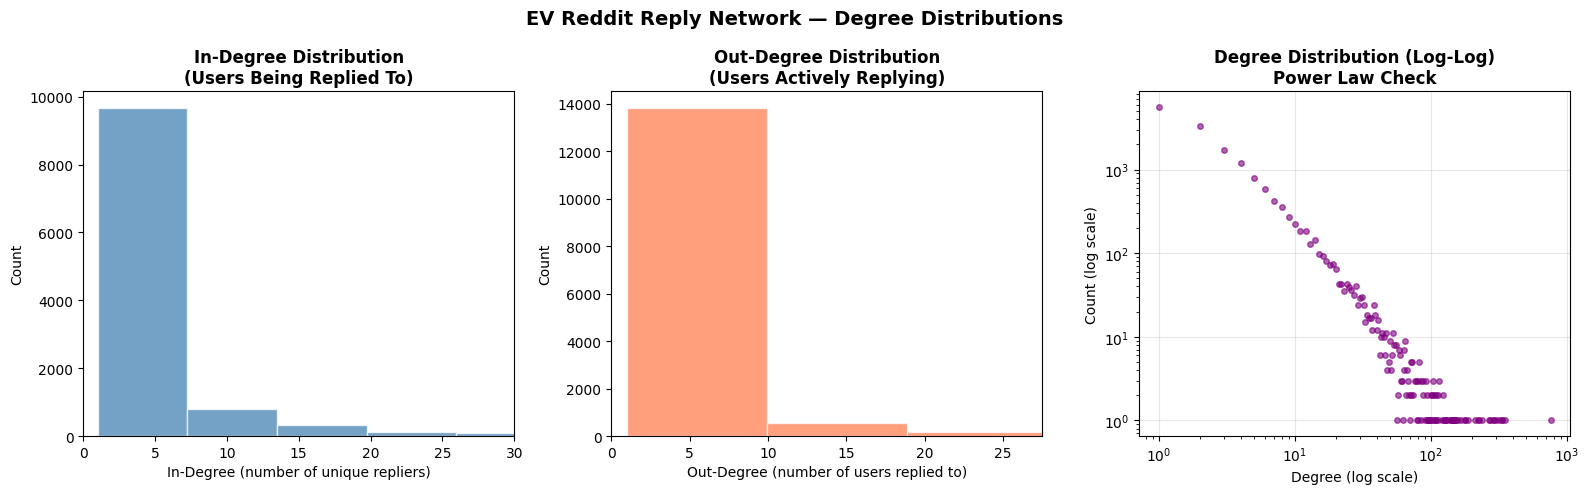

Figure saved: network_degree_distribution.png


In [7]:
# ── Plot Degree Distribution ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# In-degree distribution
axes[0].hist(
    [d for d in in_deg_vals if d > 0],
    bins=50, color='steelblue', alpha=0.75, edgecolor='white'
)
axes[0].set_title('In-Degree Distribution\n(Users Being Replied To)', fontweight='bold')
axes[0].set_xlabel('In-Degree (number of unique repliers)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, np.percentile(in_deg_vals, 99))

# Out-degree distribution
axes[1].hist(
    [d for d in out_deg_vals if d > 0],
    bins=50, color='coral', alpha=0.75, edgecolor='white'
)
axes[1].set_title('Out-Degree Distribution\n(Users Actively Replying)', fontweight='bold')
axes[1].set_xlabel('Out-Degree (number of users replied to)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, np.percentile(out_deg_vals, 99))

# Log-log degree distribution (power law check)
from collections import Counter
deg_count = Counter(all_degrees.values())
deg_vals_ll  = sorted(deg_count.keys())
deg_count_ll = [deg_count[d] for d in deg_vals_ll]
axes[2].loglog(deg_vals_ll, deg_count_ll, 'o', color='purple', alpha=0.6, markersize=4)
axes[2].set_title('Degree Distribution (Log-Log)\nPower Law Check', fontweight='bold')
axes[2].set_xlabel('Degree (log scale)')
axes[2].set_ylabel('Count (log scale)')
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'EV Reddit Reply Network — Degree Distributions',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_degree_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: network_degree_distribution.png')

## 5. Centrality Measures

We compute multiple centrality measures to identify influential users:

| Measure | What it captures |
|---|---|
| **In-degree centrality** | Who receives the most replies — popular/engaging users |
| **PageRank** | Influence weighted by the importance of who replies to you |
| **Betweenness centrality** | Users who bridge different conversation clusters |

> **Note:** For COSC 3047, we go beyond listing rankings — we interpret what each measure reveals about user roles in the EV conversation.

In [8]:
print('Computing centrality measures...')
print('(This may take a minute for large networks)')
print('-' * 50)

# ── In-Degree Centrality ──
in_deg_centrality = nx.in_degree_centrality(G)
print(f'In-degree centrality computed for {len(in_deg_centrality):,} nodes')

# ── PageRank ──
# alpha=0.85 is standard damping factor
pagerank = nx.pagerank(G, alpha=0.85, weight='weight', max_iter=200)
print(f'PageRank computed for {len(pagerank):,} nodes')

# ── Betweenness Centrality ──
# Use approximation (k=500 samples) for large networks to save time
n_nodes = G.number_of_nodes()
if n_nodes > 5000:
    k_samples = min(500, n_nodes)
    betweenness = nx.betweenness_centrality(G, k=k_samples, normalized=True, weight='weight')
    print(f'Betweenness centrality computed (approx, k={k_samples} samples)')
else:
    betweenness = nx.betweenness_centrality(G, normalized=True, weight='weight')
    print(f'Betweenness centrality computed (exact)')

print('\nAll centrality measures computed!')

Computing centrality measures...
(This may take a minute for large networks)
--------------------------------------------------
In-degree centrality computed for 16,450 nodes
PageRank computed for 16,450 nodes
Betweenness centrality computed (approx, k=500 samples)

All centrality measures computed!


In [9]:
# ── Compile centrality results into a DataFrame ──
centrality_df = pd.DataFrame({
    'user'               : list(G.nodes()),
    'in_degree'          : [in_degrees[n] for n in G.nodes()],
    'out_degree'         : [out_degrees[n] for n in G.nodes()],
    'in_degree_centrality': [in_deg_centrality[n] for n in G.nodes()],
    'pagerank'           : [pagerank[n] for n in G.nodes()],
    'betweenness'        : [betweenness[n] for n in G.nodes()],
})

# Save centrality results
centrality_df.to_csv(os.path.join(PROCESSED_DIR, 'centrality_results.csv'), index=False)
print('Centrality results saved to data/processed/centrality_results.csv')
print(f'\nShape: {centrality_df.shape}')
print(centrality_df.describe().round(6))

Centrality results saved to data/processed/centrality_results.csv

Shape: (16450, 6)
          in_degree    out_degree  in_degree_centrality      pagerank  \
count  16450.000000  16450.000000          16450.000000  16450.000000   
mean       2.909422      2.909422              0.000177      0.000061   
std        7.545509      7.787745              0.000459      0.000133   
min        0.000000      0.000000              0.000000      0.000013   
25%        0.000000      1.000000              0.000000      0.000013   
50%        1.000000      1.000000              0.000061      0.000025   
75%        3.000000      2.000000              0.000182      0.000056   
max      313.000000    448.000000              0.019029      0.006080   

        betweenness  
count  16450.000000  
mean       0.000129  
std        0.000916  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000015  
max        0.061689  


In [10]:
# ── Top 15 Users by Each Centrality Measure ──

print('=' * 60)
print('TOP 15 USERS BY PAGERANK (Most Influential)')
print('=' * 60)
top_pagerank = centrality_df.nlargest(15, 'pagerank')[['user', 'pagerank', 'in_degree', 'out_degree']]
top_pagerank['pagerank'] = top_pagerank['pagerank'].round(6)
print(top_pagerank.to_string(index=False))

print('\n' + '=' * 60)
print('TOP 15 USERS BY BETWEENNESS CENTRALITY (Bridge Users)')
print('=' * 60)
top_betweenness = centrality_df.nlargest(15, 'betweenness')[['user', 'betweenness', 'in_degree', 'out_degree']]
top_betweenness['betweenness'] = top_betweenness['betweenness'].round(6)
print(top_betweenness.to_string(index=False))

print('\n' + '=' * 60)
print('TOP 15 USERS BY IN-DEGREE CENTRALITY (Most Replied-To)')
print('=' * 60)
top_indegree = centrality_df.nlargest(15, 'in_degree')[['user', 'in_degree', 'out_degree', 'pagerank']]
print(top_indegree.to_string(index=False))

TOP 15 USERS BY PAGERANK (Most Influential)
         user  pagerank  in_degree  out_degree
user_03e404fd  0.006080        313         448
user_4d0690ed  0.003763        190         113
user_2c99702a  0.003282        194         141
user_dae603af  0.003126        180          57
user_5ab4d984  0.003094        187         131
user_1d199b81  0.002902        154         134
user_49878439  0.002527        120         154
user_b7936b51  0.002436        154         178
user_623a9827  0.002273        134          91
user_67fbb40d  0.002264        151         116
user_561d480b  0.002189        118          61
user_48346fa0  0.002169         59           5
user_13f4fedf  0.001788         84          65
user_26d80e37  0.001736         53          72
user_5f524439  0.001696        115         234

TOP 15 USERS BY BETWEENNESS CENTRALITY (Bridge Users)
         user  betweenness  in_degree  out_degree
user_03e404fd     0.061689        313         448
user_2c99702a     0.028884        194         141

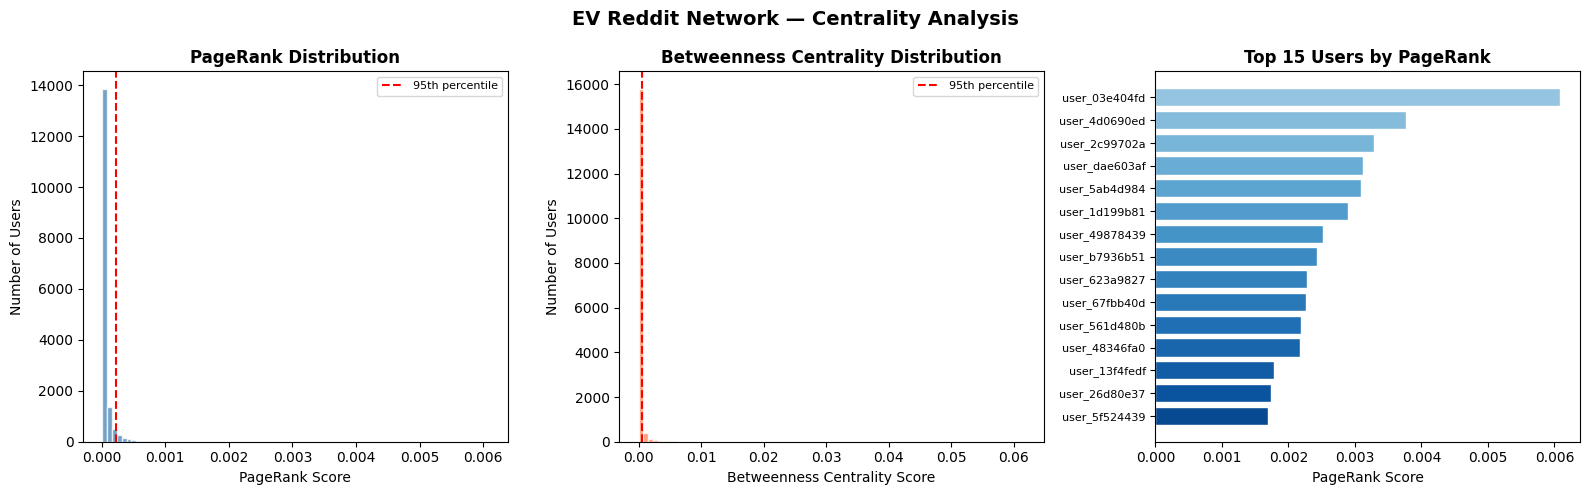

Figure saved: network_centrality_analysis.png


In [11]:
# ── Visualise Centrality Distributions ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PageRank distribution
pr_vals = centrality_df['pagerank'].values
axes[0].hist(pr_vals, bins=80, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].set_title('PageRank Distribution', fontweight='bold')
axes[0].set_xlabel('PageRank Score')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(np.percentile(pr_vals, 95), color='red', linestyle='--', label='95th percentile')
axes[0].legend(fontsize=8)

# Betweenness distribution
bt_vals = centrality_df['betweenness'].values
axes[1].hist(bt_vals, bins=80, color='coral', alpha=0.75, edgecolor='white')
axes[1].set_title('Betweenness Centrality Distribution', fontweight='bold')
axes[1].set_xlabel('Betweenness Centrality Score')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(np.percentile(bt_vals, 95), color='red', linestyle='--', label='95th percentile')
axes[1].legend(fontsize=8)

# Top 15 PageRank bar chart
top15 = centrality_df.nlargest(15, 'pagerank')
bars = axes[2].barh(
    range(len(top15)), top15['pagerank'],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top15))),
    edgecolor='white'
)
axes[2].set_yticks(range(len(top15)))
axes[2].set_yticklabels(top15['user'].values, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_title('Top 15 Users by PageRank', fontweight='bold')
axes[2].set_xlabel('PageRank Score')

plt.suptitle('EV Reddit Network — Centrality Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_centrality_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: network_centrality_analysis.png')

## 6. Community Detection (Louvain Algorithm)

We use the **Louvain algorithm** to detect communities in the reply network. Louvain is a modularity-maximisation method — it finds groups of users who reply to each other more than would be expected by chance.

- **Directed graph → converted to undirected** for Louvain (as required by the algorithm)
- **Modularity Q** measures community quality: Q > 0.3 is generally considered meaningful
- Communities here represent **conversation clusters** — groups of users who predominantly interact within their group

In [12]:
print('Running community detection...')
print('-' * 50)

# Convert to undirected for Louvain (standard practice)
G_undirected = G.to_undirected()
print(f'Undirected graph: {G_undirected.number_of_nodes():,} nodes, {G_undirected.number_of_edges():,} edges')

# Extract the largest connected component for community detection
largest_cc = max(nx.connected_components(G_undirected), key=len)
G_lcc = G_undirected.subgraph(largest_cc).copy()
print(f'Largest connected component: {G_lcc.number_of_nodes():,} nodes, {G_lcc.number_of_edges():,} edges')
print(f'  ({G_lcc.number_of_nodes()/G_undirected.number_of_nodes()*100:.1f}% of total nodes)')

# ── Run Louvain ──
if LOUVAIN_AVAILABLE:
    partition = community_louvain.best_partition(G_lcc, weight='weight', random_state=42)
    modularity = community_louvain.modularity(partition, G_lcc, weight='weight')
    algo_name = 'Louvain'
    print(f'\nLouvain algorithm complete!')
else:
    # Fallback: networkx greedy modularity
    communities_gen = nx.community.greedy_modularity_communities(G_lcc, weight='weight')
    communities_list = list(communities_gen)
    partition = {}
    for comm_id, comm_nodes in enumerate(communities_list):
        for node in comm_nodes:
            partition[node] = comm_id
    modularity = nx.community.modularity(
        G_lcc,
        [{n for n, c in partition.items() if c == cid} for cid in set(partition.values())],
        weight='weight'
    )
    algo_name = 'Greedy Modularity'
    print(f'\nGreedy modularity algorithm complete (fallback)!')

# Summarise communities
from collections import Counter
comm_sizes = Counter(partition.values())
num_communities = len(comm_sizes)

print(f'\n{algo_name} Community Detection Results:')
print(f'  Communities detected : {num_communities}')
print(f'  Modularity Q         : {modularity:.4f}')
print(f'  (Q > 0.3 indicates meaningful community structure)')
print(f'  Largest community    : {max(comm_sizes.values()):,} nodes')
print(f'  Smallest community   : {min(comm_sizes.values()):,} nodes')
print(f'  Median community size: {np.median(list(comm_sizes.values())):.0f} nodes')

Running community detection...
--------------------------------------------------
Undirected graph: 16,450 nodes, 38,947 edges
Largest connected component: 15,891 nodes, 38,632 edges
  (96.6% of total nodes)

Louvain algorithm complete!

Louvain Community Detection Results:
  Communities detected : 48
  Modularity Q         : 0.4887
  (Q > 0.3 indicates meaningful community structure)
  Largest community    : 1,002 nodes
  Smallest community   : 42 nodes
  Median community size: 290 nodes


In [13]:
# Store community labels on all nodes (nodes not in LCC get -1)
nx.set_node_attributes(G, -1, 'community')
for node, comm in partition.items():
    if G.has_node(node):
        G.nodes[node]['community'] = comm

# Add centrality as node attributes (useful for Gephi)
nx.set_node_attributes(G, pagerank, 'pagerank')
nx.set_node_attributes(G, betweenness, 'betweenness')
nx.set_node_attributes(G, in_deg_centrality, 'in_degree_centrality')
nx.set_node_attributes(G, in_degrees, 'in_degree')
nx.set_node_attributes(G, out_degrees, 'out_degree')

print('Node attributes added: community, pagerank, betweenness, in_degree_centrality')

# Show top communities by size
top_communities = sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)[:15]
print(f'\nTop 15 communities by size:')
print(f'{"Community ID":>15} {"Size":>10} {"% of LCC":>10}')
print('-' * 40)
for cid, size in top_communities:
    pct = size / G_lcc.number_of_nodes() * 100
    print(f'{cid:>15} {size:>10,} {pct:>9.1f}%')

Node attributes added: community, pagerank, betweenness, in_degree_centrality

Top 15 communities by size:
   Community ID       Size   % of LCC
----------------------------------------
              4      1,002       6.3%
             13        684       4.3%
             11        598       3.8%
             20        590       3.7%
             18        531       3.3%
             10        528       3.3%
             17        524       3.3%
             25        521       3.3%
              3        486       3.1%
             44        486       3.1%
             47        483       3.0%
             27        470       3.0%
              2        460       2.9%
             42        457       2.9%
             21        426       2.7%


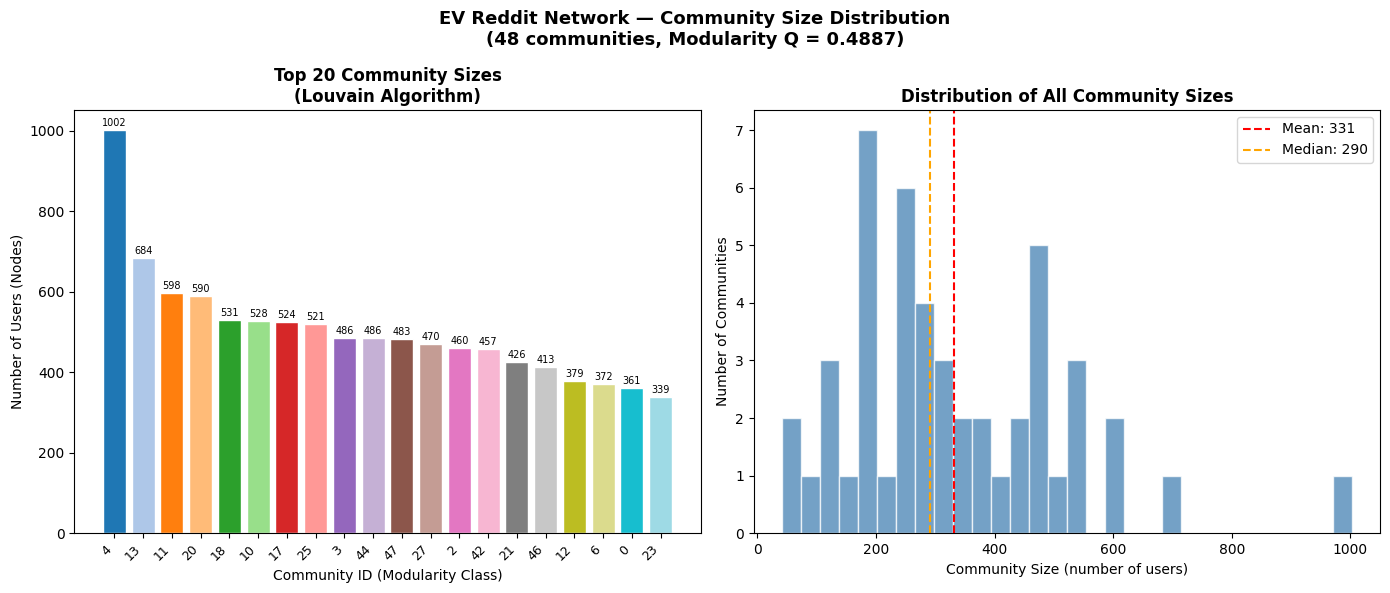

Figure saved: network_community_sizes.png


In [14]:
# ── Plot Community Size Distribution (mirrors sample report Graph 4) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Community size bar chart (top 20)
top20_comm = sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)[:20]
comm_ids   = [str(c[0]) for c in top20_comm]
comm_szs   = [c[1] for c in top20_comm]

bars = axes[0].bar(
    range(len(comm_ids)), comm_szs,
    color=plt.cm.tab20(np.linspace(0, 1, len(comm_ids))),
    edgecolor='white'
)
axes[0].set_xticks(range(len(comm_ids)))
axes[0].set_xticklabels(comm_ids, rotation=45, ha='right', fontsize=9)
axes[0].set_title(f'Top 20 Community Sizes\n({algo_name} Algorithm)', fontweight='bold')
axes[0].set_xlabel('Community ID (Modularity Class)')
axes[0].set_ylabel('Number of Users (Nodes)')
for i, (bar, sz) in enumerate(zip(bars, comm_szs)):
    if sz > max(comm_szs) * 0.05:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(sz), ha='center', va='bottom', fontsize=7)

# All community size distribution (histogram)
all_sizes = list(comm_sizes.values())
axes[1].hist(all_sizes, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].set_title('Distribution of All Community Sizes', fontweight='bold')
axes[1].set_xlabel('Community Size (number of users)')
axes[1].set_ylabel('Number of Communities')
axes[1].axvline(np.mean(all_sizes), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_sizes):.0f}')
axes[1].axvline(np.median(all_sizes), color='orange', linestyle='--',
                label=f'Median: {np.median(all_sizes):.0f}')
axes[1].legend()

plt.suptitle(
    f'EV Reddit Network — Community Size Distribution\n'
    f'({num_communities} communities, Modularity Q = {modularity:.4f})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_community_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: network_community_sizes.png')

## 7. Network Visualisation

Due to the scale of the full network (23,000+ nodes), we visualise:
1. **A sampled subgraph** — the top-N users by degree, coloured by community
2. **A community network** — each node is a community, sized by membership

This mirrors the approach used in the sample Trump/ASX report, where the authors visualised subsets of the network for clarity.

Subgraph for visualisation:
  Nodes : 300
  Edges : 3108


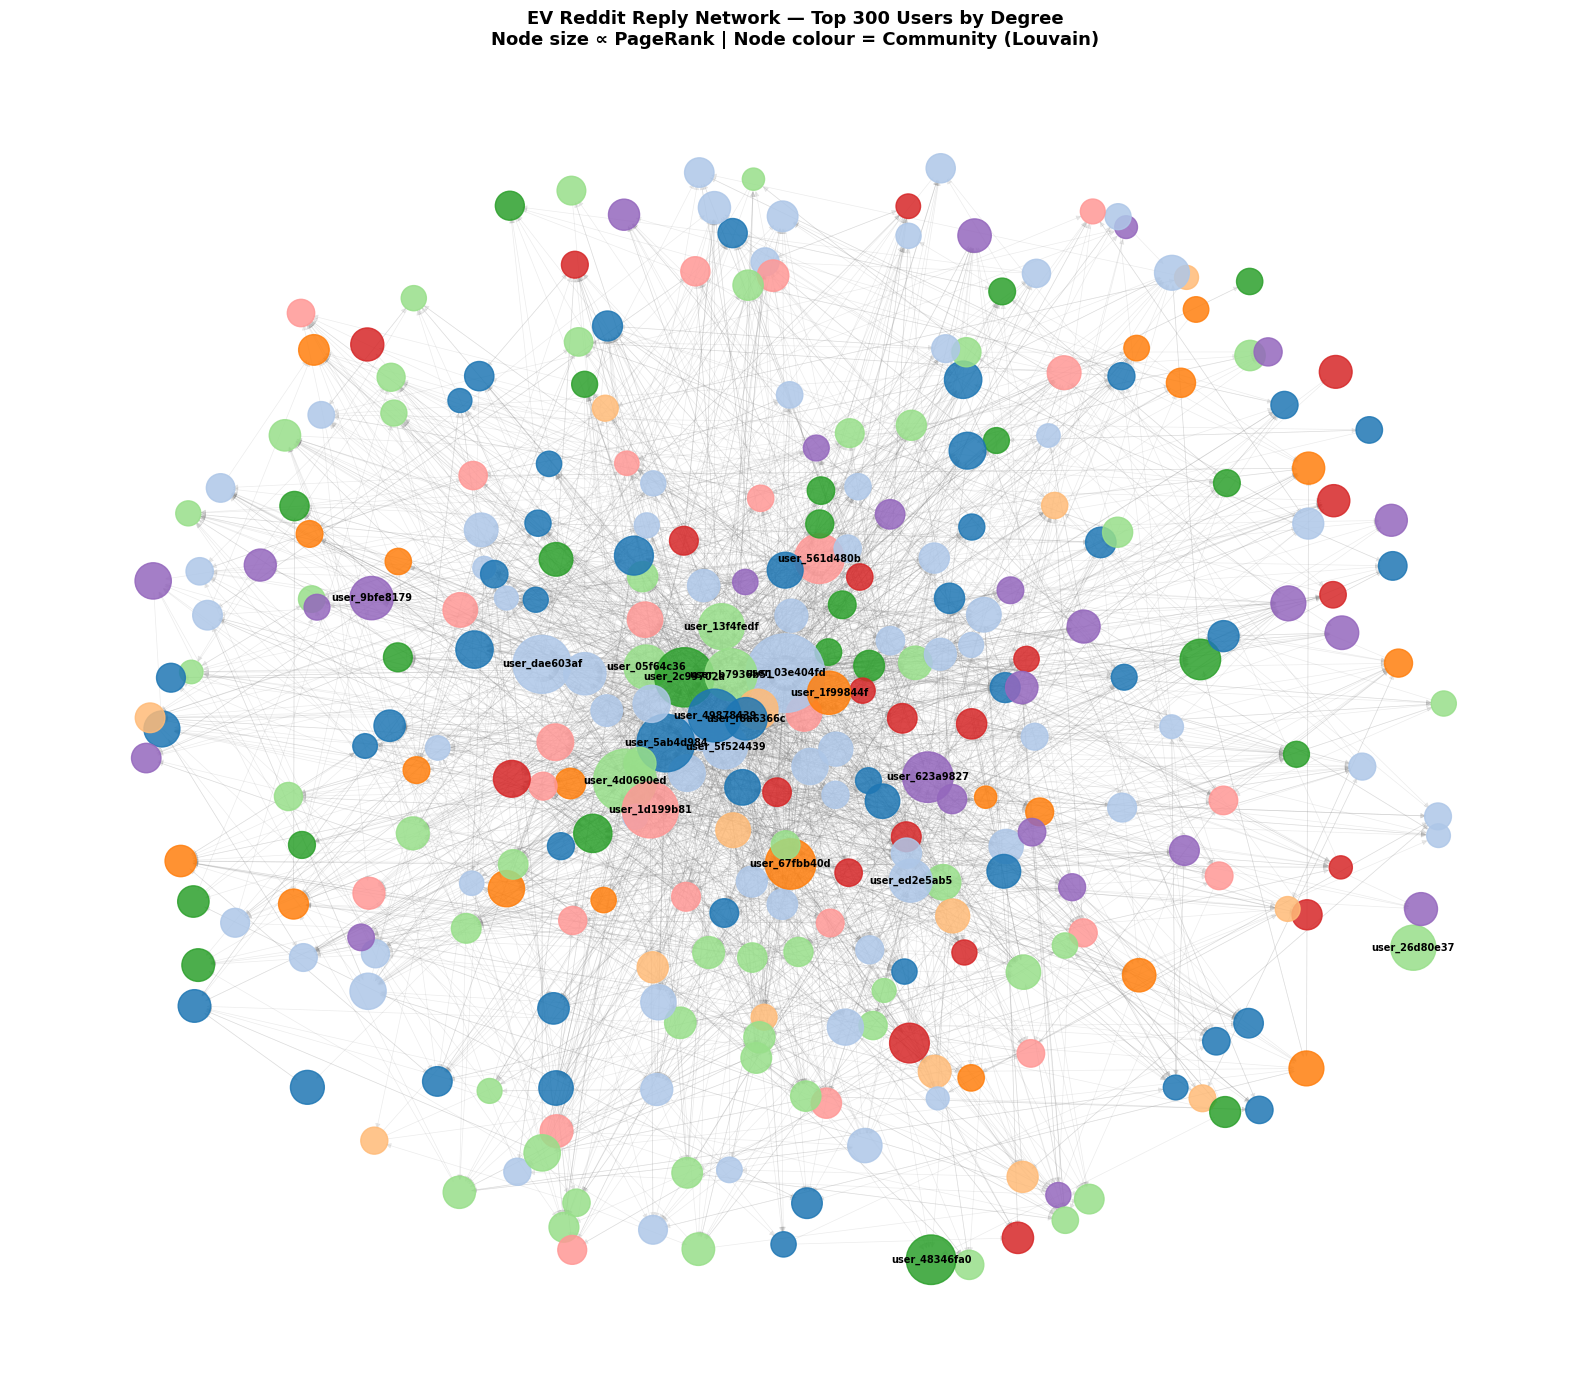

Figure saved: network_visualisation_subgraph.png


In [15]:
# ── Subgraph: Top users by degree ──
# Sample top N users (by total degree) for visualisation
N_VIZ = 300  # number of top users to visualise

# Get top N nodes by total degree
top_nodes = sorted(all_degrees.items(), key=lambda x: x[1], reverse=True)[:N_VIZ]
top_node_ids = [n for n, d in top_nodes]

# Extract induced subgraph
G_sub = G.subgraph(top_node_ids).copy()
print(f'Subgraph for visualisation:')
print(f'  Nodes : {G_sub.number_of_nodes()}')
print(f'  Edges : {G_sub.number_of_edges()}')

# Assign colours by community
unique_comms = sorted(set(
    G.nodes[n].get('community', -1)
    for n in G_sub.nodes()
))
color_map = plt.cm.tab20(np.linspace(0, 1, max(len(unique_comms), 20)))
comm_color_dict = {c: color_map[i % 20] for i, c in enumerate(unique_comms)}
node_colors = [comm_color_dict.get(G.nodes[n].get('community', -1), 'grey')
               for n in G_sub.nodes()]

# Node sizes proportional to PageRank
pr_sub = [pagerank.get(n, 0) for n in G_sub.nodes()]
max_pr = max(pr_sub) if max(pr_sub) > 0 else 1
node_sizes = [200 + 3000 * (p / max_pr) for p in pr_sub]

fig, ax = plt.subplots(figsize=(16, 14))
pos = nx.spring_layout(G_sub, k=0.8, seed=42, iterations=50)

# Draw edges (thin, transparent)
nx.draw_networkx_edges(
    G_sub, pos, ax=ax,
    alpha=0.15, width=0.5,
    edge_color='grey',
    arrows=True, arrowsize=8
)

# Draw nodes
nx.draw_networkx_nodes(
    G_sub, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.85
)

# Label only top 20 by PageRank
top20_nodes = set(centrality_df.nlargest(20, 'pagerank')['user'].values)
label_dict = {n: n for n in G_sub.nodes() if n in top20_nodes}
nx.draw_networkx_labels(
    G_sub, pos, labels=label_dict, ax=ax,
    font_size=7, font_weight='bold', font_color='black'
)

ax.set_title(
    f'EV Reddit Reply Network — Top {N_VIZ} Users by Degree\n'
    f'Node size ∝ PageRank | Node colour = Community (Louvain)',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_visualisation_subgraph.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: network_visualisation_subgraph.png')

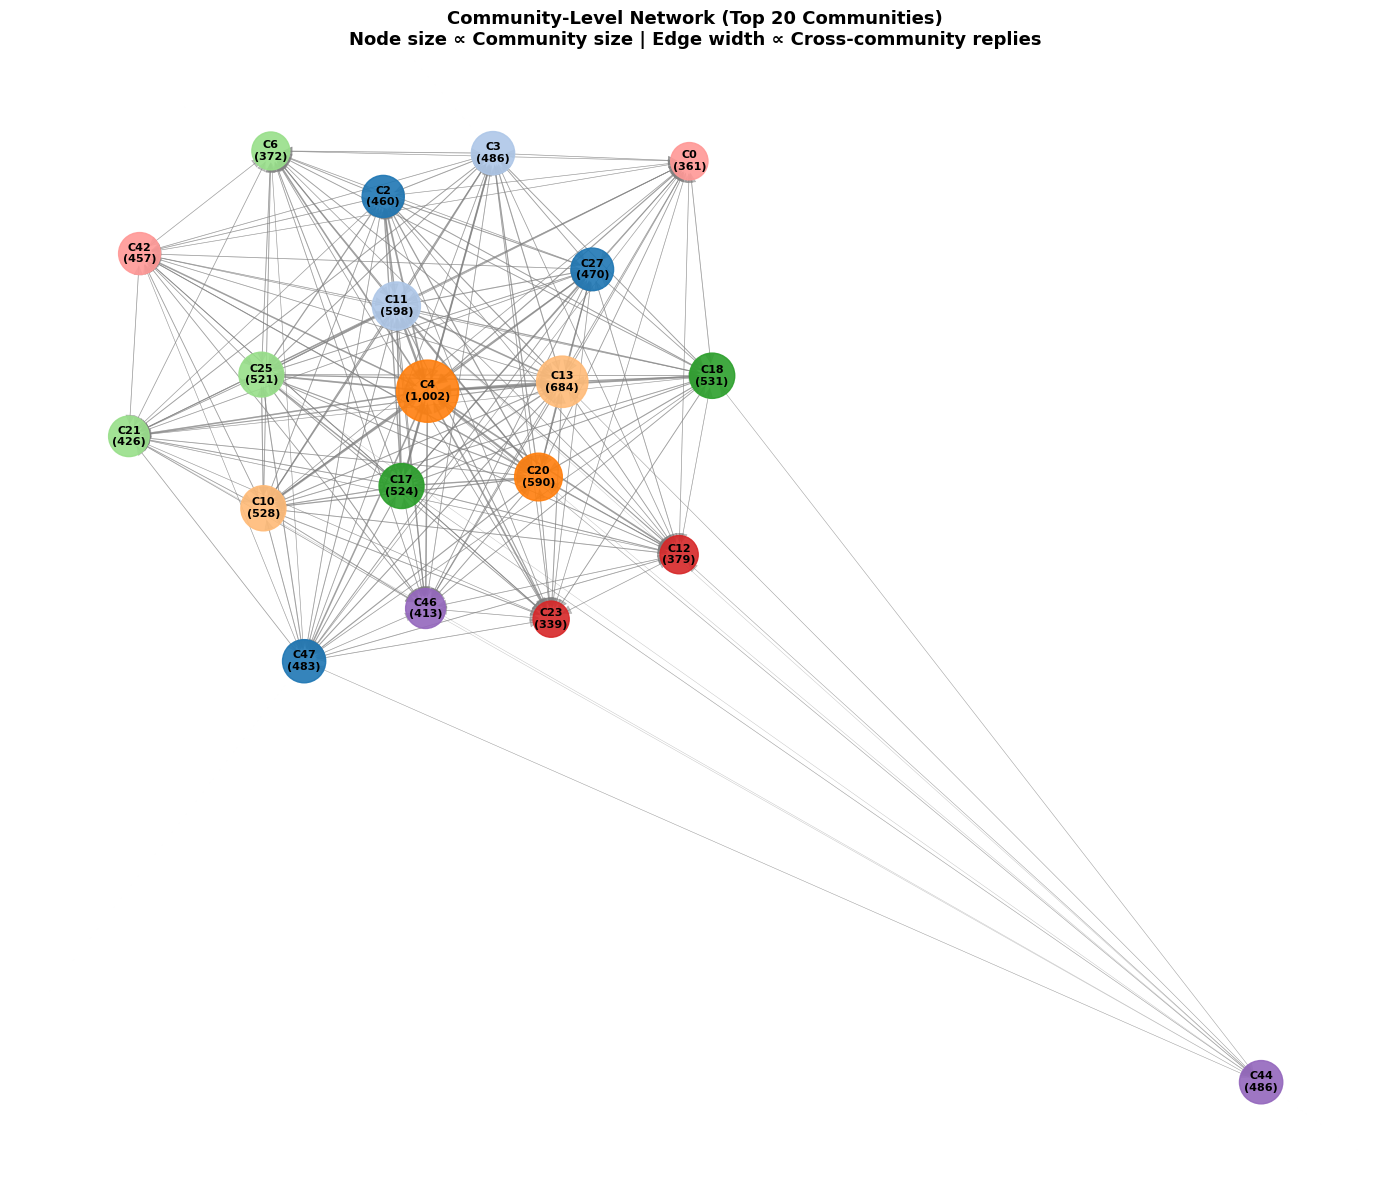

Figure saved: network_community_graph.png


In [16]:
# ── Community-level network (macro view) ──
# Collapse graph: each community = one node, edges = inter-community connections
# Only include top communities for clarity

TOP_COMMS = 20
top_comm_ids = set(c for c, _ in sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)[:TOP_COMMS])

# Build community-level graph
G_comm = nx.DiGraph()
for u, v, data in G.edges(data=True):
    cu = G.nodes[u].get('community', -1)
    cv = G.nodes[v].get('community', -1)
    if cu in top_comm_ids and cv in top_comm_ids and cu != cv:
        if G_comm.has_edge(cu, cv):
            G_comm[cu][cv]['weight'] += data.get('weight', 1)
        else:
            G_comm.add_edge(cu, cv, weight=data.get('weight', 1))

# Node size = community size
comm_node_sizes = [comm_sizes.get(n, 10) * 2 for n in G_comm.nodes()]
comm_colors     = [color_map[i % 20] for i, n in enumerate(G_comm.nodes())]
edge_widths     = [min(G_comm[u][v]['weight'] / 100 + 0.3, 5) for u, v in G_comm.edges()]

fig, ax = plt.subplots(figsize=(14, 12))
pos_comm = nx.spring_layout(G_comm, k=2.0, seed=42)

nx.draw_networkx_edges(G_comm, pos_comm, ax=ax,
                        width=edge_widths, alpha=0.5,
                        edge_color='grey', arrows=True, arrowsize=15)
nx.draw_networkx_nodes(G_comm, pos_comm, ax=ax,
                        node_color=comm_colors,
                        node_size=comm_node_sizes, alpha=0.9)
comm_labels = {n: f'C{n}\n({comm_sizes.get(n, 0):,})' for n in G_comm.nodes()}
nx.draw_networkx_labels(G_comm, pos_comm, labels=comm_labels, ax=ax,
                         font_size=8, font_weight='bold')

ax.set_title(
    f'Community-Level Network (Top {TOP_COMMS} Communities)\n'
    f'Node size ∝ Community size | Edge width ∝ Cross-community replies',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_community_graph.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: network_community_graph.png')

## 8. Network Summary Statistics Table

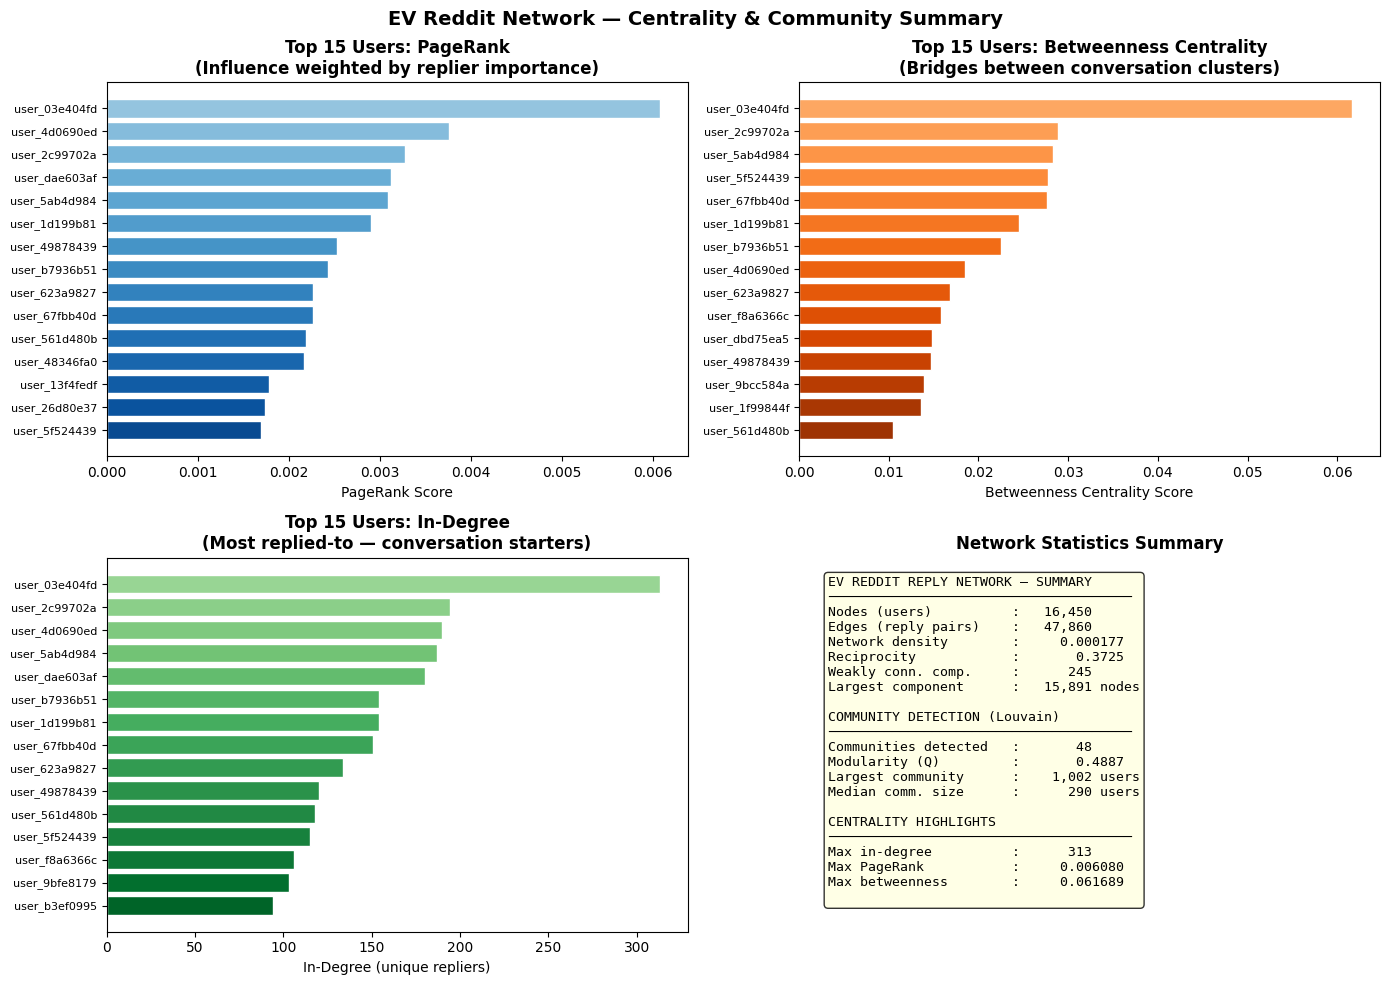

Figure saved: network_analysis_overview.png


In [17]:
# ── Comprehensive summary figure for report ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Top 15 by PageRank
top15_pr = centrality_df.nlargest(15, 'pagerank')
axes[0,0].barh(
    range(15), top15_pr['pagerank'],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, 15)), edgecolor='white'
)
axes[0,0].set_yticks(range(15))
axes[0,0].set_yticklabels(top15_pr['user'], fontsize=8)
axes[0,0].invert_yaxis()
axes[0,0].set_title('Top 15 Users: PageRank\n(Influence weighted by replier importance)', fontweight='bold')
axes[0,0].set_xlabel('PageRank Score')

# Plot 2: Top 15 by Betweenness
top15_bt = centrality_df.nlargest(15, 'betweenness')
axes[0,1].barh(
    range(15), top15_bt['betweenness'],
    color=plt.cm.Oranges(np.linspace(0.4, 0.9, 15)), edgecolor='white'
)
axes[0,1].set_yticks(range(15))
axes[0,1].set_yticklabels(top15_bt['user'], fontsize=8)
axes[0,1].invert_yaxis()
axes[0,1].set_title('Top 15 Users: Betweenness Centrality\n(Bridges between conversation clusters)', fontweight='bold')
axes[0,1].set_xlabel('Betweenness Centrality Score')

# Plot 3: Top 15 by In-Degree
top15_id = centrality_df.nlargest(15, 'in_degree')
axes[1,0].barh(
    range(15), top15_id['in_degree'],
    color=plt.cm.Greens(np.linspace(0.4, 0.9, 15)), edgecolor='white'
)
axes[1,0].set_yticks(range(15))
axes[1,0].set_yticklabels(top15_id['user'], fontsize=8)
axes[1,0].invert_yaxis()
axes[1,0].set_title('Top 15 Users: In-Degree\n(Most replied-to — conversation starters)', fontweight='bold')
axes[1,0].set_xlabel('In-Degree (unique repliers)')

# Plot 4: Network summary statistics as text
axes[1,1].axis('off')
summary_text = (
    f"EV REDDIT REPLY NETWORK — SUMMARY\n"
    f"{'─'*38}\n"
    f"Nodes (users)          : {G.number_of_nodes():>8,}\n"
    f"Edges (reply pairs)    : {G.number_of_edges():>8,}\n"
    f"Network density        : {density:>12.6f}\n"
    f"Reciprocity            : {reciprocity:>12.4f}\n"
    f"Weakly conn. comp.     : {len(wccs):>8,}\n"
    f"Largest component      : {lcc_size:>8,} nodes\n"
    f"\n"
    f"COMMUNITY DETECTION ({algo_name})\n"
    f"{'─'*38}\n"
    f"Communities detected   : {num_communities:>8,}\n"
    f"Modularity (Q)         : {modularity:>12.4f}\n"
    f"Largest community      : {max(comm_sizes.values()):>8,} users\n"
    f"Median comm. size      : {np.median(list(comm_sizes.values())):>8.0f} users\n"
    f"\n"
    f"CENTRALITY HIGHLIGHTS\n"
    f"{'─'*38}\n"
    f"Max in-degree          : {max(in_deg_vals):>8,}\n"
    f"Max PageRank           : {max(pagerank.values()):>12.6f}\n"
    f"Max betweenness        : {max(betweenness.values()):>12.6f}\n"
)
axes[1,1].text(
    0.05, 0.95, summary_text,
    transform=axes[1,1].transAxes,
    fontsize=9.5, verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
axes[1,1].set_title('Network Statistics Summary', fontweight='bold')

plt.suptitle(
    'EV Reddit Network — Centrality & Community Summary',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_analysis_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: network_analysis_overview.png')

## 9. Save Graph (GraphML) for Gephi

In [18]:
# Save full graph as GraphML (can be loaded into Gephi for further visualisation)
graphml_path = os.path.join(GRAPH_DIR, 'ev_reply_network.graphml')

# GraphML requires string node IDs and numeric/string attributes
# Convert all node attributes to safe types
G_save = G.copy()
for node in G_save.nodes():
    for attr in ['pagerank', 'betweenness', 'in_degree_centrality']:
        v = G_save.nodes[node].get(attr, 0.0)
        G_save.nodes[node][attr] = float(v) if v is not None else 0.0
    G_save.nodes[node]['in_degree']  = int(G_save.nodes[node].get('in_degree', 0))
    G_save.nodes[node]['out_degree'] = int(G_save.nodes[node].get('out_degree', 0))
    G_save.nodes[node]['community']  = int(G_save.nodes[node].get('community', -1))

nx.write_graphml(G_save, graphml_path)
size_mb = os.path.getsize(graphml_path) / (1024 * 1024)
print(f'Graph saved as GraphML: {graphml_path}')
print(f'File size: {size_mb:.1f} MB')
print(f'  Load into Gephi → ForceAtlas2 layout → colour by community attribute')
print(f'  Node size ∝ pagerank attribute')

Graph saved as GraphML: ../data/processed/ev_reply_network.graphml
File size: 8.7 MB
  Load into Gephi → ForceAtlas2 layout → colour by community attribute
  Node size ∝ pagerank attribute


## 10. Export Results for Discussion Notebook

In [19]:
# Save community membership for each user
community_membership = pd.DataFrame([
    {
        'user'           : node,
        'community'      : partition.get(node, -1),
        'in_degree'      : in_degrees.get(node, 0),
        'out_degree'     : out_degrees.get(node, 0),
        'pagerank'       : pagerank.get(node, 0.0),
        'betweenness'    : betweenness.get(node, 0.0),
    }
    for node in G_lcc.nodes()
])

community_membership.to_csv(
    os.path.join(PROCESSED_DIR, 'community_membership.csv'), index=False
)
print(f'Community membership saved: {len(community_membership):,} users')

# Save top users summary
top_users_summary = centrality_df.nlargest(100, 'pagerank').copy()
top_users_summary.to_csv(
    os.path.join(PROCESSED_DIR, 'top_users_centrality.csv'), index=False
)
print(f'Top 100 users by PageRank saved')

Community membership saved: 15,891 users
Top 100 users by PageRank saved


## 11. Final Summary

In [20]:
print('=' * 60)
print('NETWORK ANALYSIS COMPLETE')
print('=' * 60)

print(f'\nNETWORK STRUCTURE')
print(f'  Nodes (unique users)        : {G.number_of_nodes():,}')
print(f'  Edges (reply interactions)  : {G.number_of_edges():,}')
print(f'  Type                        : Directed, Weighted')
print(f'  Network density             : {density:.6f}')
print(f'  Reciprocity                 : {reciprocity:.4f}')
print(f'  Weakly connected components : {len(wccs):,}')
print(f'  Largest component           : {lcc_size:,} nodes ({lcc_size/G.number_of_nodes()*100:.1f}%)')

print(f'\nCOMMUNITY DETECTION ({algo_name})')
print(f'  Communities found           : {num_communities}')
print(f'  Modularity Q                : {modularity:.4f}')
print(f'  Largest community           : {max(comm_sizes.values()):,} users')

print(f'\nCENTRALITY')
top_pr_user = centrality_df.nlargest(1, 'pagerank').iloc[0]
top_bt_user = centrality_df.nlargest(1, 'betweenness').iloc[0]
top_id_user = centrality_df.nlargest(1, 'in_degree').iloc[0]
print(f'  Top PageRank user           : {top_pr_user["user"]} (score: {top_pr_user["pagerank"]:.6f})')
print(f'  Top betweenness user        : {top_bt_user["user"]} (score: {top_bt_user["betweenness"]:.6f})')
print(f'  Top in-degree user          : {top_id_user["user"]} (in-degree: {int(top_id_user["in_degree"])})')

print(f'\nFILES SAVED')
print(f'  data/processed/centrality_results.csv')
print(f'  data/processed/community_membership.csv')
print(f'  data/processed/top_users_centrality.csv')
print(f'  data/processed/ev_reply_network.graphml')
print(f'  reports/figures/network_degree_distribution.png')
print(f'  reports/figures/network_centrality_analysis.png')
print(f'  reports/figures/network_community_sizes.png')
print(f'  reports/figures/network_community_graph.png')
print(f'  reports/figures/network_visualisation_subgraph.png')
print(f'  reports/figures/network_analysis_overview.png')

print('=' * 60)

NETWORK ANALYSIS COMPLETE

NETWORK STRUCTURE
  Nodes (unique users)        : 16,450
  Edges (reply interactions)  : 47,860
  Type                        : Directed, Weighted
  Network density             : 0.000177
  Reciprocity                 : 0.3725
  Weakly connected components : 245
  Largest component           : 15,891 nodes (96.6%)

COMMUNITY DETECTION (Louvain)
  Communities found           : 48
  Modularity Q                : 0.4887
  Largest community           : 1,002 users

CENTRALITY
  Top PageRank user           : user_03e404fd (score: 0.006080)
  Top betweenness user        : user_03e404fd (score: 0.061689)
  Top in-degree user          : user_03e404fd (in-degree: 313)

FILES SAVED
  data/processed/centrality_results.csv
  data/processed/community_membership.csv
  data/processed/top_users_centrality.csv
  data/processed/ev_reply_network.graphml
  reports/figures/network_degree_distribution.png
  reports/figures/network_centrality_analysis.png
  reports/figures/network_